<a href="https://colab.research.google.com/github/Paridhi004/The-Self-Pruning-Neural-Network/blob/main/The_Self_Pruning_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


100%|██████████| 170M/170M [00:02<00:00, 68.8MB/s]



Training with lambda = 1e-05
Lambda=1e-05 | Epoch 1/10 | Loss=3750.8525
Lambda=1e-05 | Epoch 2/10 | Loss=3196.8332
Lambda=1e-05 | Epoch 3/10 | Loss=2767.5368
Lambda=1e-05 | Epoch 4/10 | Loss=2421.9254
Lambda=1e-05 | Epoch 5/10 | Loss=2146.5332
Lambda=1e-05 | Epoch 6/10 | Loss=1929.9271
Lambda=1e-05 | Epoch 7/10 | Loss=1755.7020
Lambda=1e-05 | Epoch 8/10 | Loss=1616.4924
Lambda=1e-05 | Epoch 9/10 | Loss=1500.0168
Lambda=1e-05 | Epoch 10/10 | Loss=1405.1547

Training with lambda = 0.0001
Lambda=0.0001 | Epoch 1/10 | Loss=31376.0092
Lambda=0.0001 | Epoch 2/10 | Loss=26088.6477
Lambda=0.0001 | Epoch 3/10 | Loss=21284.3482
Lambda=0.0001 | Epoch 4/10 | Loss=17134.4097
Lambda=0.0001 | Epoch 5/10 | Loss=13728.1253
Lambda=0.0001 | Epoch 6/10 | Loss=11041.7633
Lambda=0.0001 | Epoch 7/10 | Loss=8971.0245
Lambda=0.0001 | Epoch 8/10 | Loss=7387.3190
Lambda=0.0001 | Epoch 9/10 | Loss=6171.6327
Lambda=0.0001 | Epoch 10/10 | Loss=5229.4662

Training with lambda = 0.001
Lambda=0.001 | Epoch 1/10 | Los

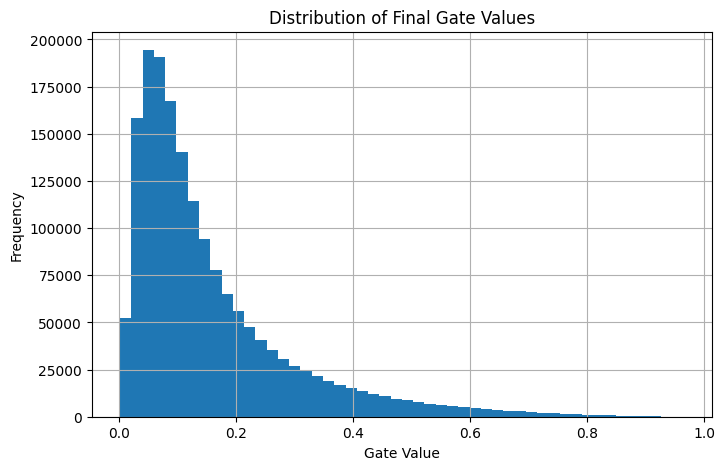

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import os

# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
LAMBDA_VALUES = [1e-5, 1e-4, 1e-3]
THRESHOLD = 1e-2


# CIFAR-10 Data
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Learnable gate scores (same shape as weight)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


def compute_sparsity_loss(model):
    loss = 0.0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
    return loss

def compute_sparsity_level(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100.0 * pruned / total


def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)

            total += y.size(0)
            correct += (preds == y).sum().item()

    return 100.0 * correct / total

def train_model(lambda_val):
    model = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            outputs = model(x)
            classification_loss = criterion(outputs, y)
            sparsity_loss = compute_sparsity_loss(model)

            total_loss = classification_loss + lambda_val * sparsity_loss
            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()

        print(f"Lambda={lambda_val} | Epoch {epoch+1}/{EPOCHS} | Loss={running_loss:.4f}")

    acc = evaluate(model)
    sparsity = compute_sparsity_level(model)

    return model, acc, sparsity


results = []
best_model = None
best_acc = 0

for lam in LAMBDA_VALUES:
    print("\nTraining with lambda =", lam)
    model, acc, sparsity = train_model(lam)

    results.append({
        "Lambda": lam,
        "Test Accuracy": round(acc, 2),
        "Sparsity (%)": round(sparsity, 2)
    })

    if acc > best_acc:
        best_acc = acc
        best_model = model


df = pd.DataFrame(results)
print("\nFinal Results:")
print(df)

df.to_csv("results.csv", index=False)

all_gates = []

for module in best_model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
        all_gates.extend(gates)

plt.figure(figsize=(8,5))
plt.hist(all_gates, bins=50)
plt.title("Distribution of Final Gate Values")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("gate_distribution.png")
plt.show()